# Dự đoán độc tính bằng Multi-task Deep Learning
## Dataset: Tox21

**Pipeline:**
1. Đọc  từ `tox21.csv` (7831 phân tử, 12 tasks)
2. Tính **ECFP fingerprints (2048-bit)** từ chuỗi SMILES qua RDKit
3. Huấn luyện **Multi-task DNN** với shared layers + task-specific heads
4. Đánh giá AUC-ROC trên tập test cho từng task


## 1. Cài đặt thư viện

In [76]:
# Chạy 1 lần nếu thiếu
# !pip install torch scikit-learn pandas numpy matplotlib rdkit-pypi
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

try:
    from rdkit import Chem
except ImportError:
    install("rdkit-pypi")

import warnings
warnings.filterwarnings("ignore")
print("✓ Thư viện sẵn sàng")


✓ Thư viện sẵn sàng


## 2. Import & Cấu hình

In [77]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# ── Cấu hình v15 ────────────────────────────────────────────────────────
SEED         = 42
BATCH_SIZE   = 256
EPOCHS       = 100
LR           = 5e-4
PATIENCE     = 25
DROPOUT      = 0.5
WEIGHT_DECAY = 5e-3
GRAD_CLIP    = 1.0
NOISE_STD    = 0.085
LABEL_SMOOTH = 0.0          # floor train loss, thu hẹp gap
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(SEED)
np.random.seed(SEED)

TASKS = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase",
    "NR-ER", "NR-ER-LBD", "NR-PPAR-gamma",
    "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53"
]

print(f"Thiết bị : {DEVICE}")
print(f"Số tasks : {len(TASKS)}")
print(f"v20: D={DROPOUT}, WD={WEIGHT_DECAY}, LS={LABEL_SMOOTH}")


Thiết bị : cpu
Số tasks : 12
v20: D=0.5, WD=0.005, LS=0.0


## 3. Đọc  từ `tox21.csv`

In [78]:
# ── Đường dẫn file CSV ────────────────────────────────────────────────
CSV_PATH = "tox21.csv"   # chỉnh lại nếu file ở thư mục khác

df = pd.read_csv(CSV_PATH)
print(f"Kích thước DataFrame : {df.shape}")
print(f"Các cột              : {df.columns.tolist()}")
df.head(3)


Kích thước DataFrame : (7831, 14)
Các cột              : ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'mol_id', 'smiles']


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...


In [79]:
# Thống kê nhãn
label_stats = pd.DataFrame({
    "Tổng có nhãn": [df[t].notna().sum() for t in TASKS],
    "Dương tính"  : [df[t].eq(1).sum()    for t in TASKS],
    "Âm tính"     : [df[t].eq(0).sum()    for t in TASKS],
    "Tỷ lệ NaN"   : [f"{df[t].isna().mean():.1%}" for t in TASKS],
    "Tỷ lệ dương" : [f"{df[t].eq(1).mean():.1%}"  for t in TASKS],
}, index=TASKS)
print(label_stats.to_string())


               Tổng có nhãn  Dương tính  Âm tính Tỷ lệ NaN Tỷ lệ dương
NR-AR                  7265         309     6956      7.2%        3.9%
NR-AR-LBD              6758         237     6521     13.7%        3.0%
NR-AhR                 6549         768     5781     16.4%        9.8%
NR-Aromatase           5821         300     5521     25.7%        3.8%
NR-ER                  6193         793     5400     20.9%       10.1%
NR-ER-LBD              6955         350     6605     11.2%        4.5%
NR-PPAR-gamma          6450         186     6264     17.6%        2.4%
SR-ARE                 5832         942     4890     25.5%       12.0%
SR-ATAD5               7072         264     6808      9.7%        3.4%
SR-HSE                 6467         372     6095     17.4%        4.8%
SR-MMP                 5810         918     4892     25.8%       11.7%
SR-p53                 6774         423     6351     13.5%        5.4%


## 4. Tính ECFP Fingerprints từ SMILES

In [80]:
def smiles_to_ecfp(smiles_series, radius=2, n_bits=2048):
    """
    Chuyển chuỗi SMILES → ECFP4 fingerprint nhị phân (numpy array).
    Phân tử không hợp lệ → vector 0 (và cờ valid=False).
    """
    fps    = np.zeros((len(smiles_series), n_bits), dtype=np.float32)
    valid  = np.ones(len(smiles_series), dtype=bool)

    for i, smi in enumerate(smiles_series):
        mol = Chem.MolFromSmiles(str(smi)) if pd.notna(smi) else None
        if mol is None:
            valid[i] = False
            continue
        arr = np.zeros((n_bits,), dtype=np.uint8)
        fp  = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
        DataStructs.ConvertToNumpyArray(fp, arr)
        fps[i] = arr.astype(np.float32)

    return fps, valid

print("Đang tính ECFP4 fingerprints (2048-bit)…")
X_all, valid_mask = smiles_to_ecfp(df["smiles"])

n_invalid = (~valid_mask).sum()
print(f"  Tổng phân tử      : {len(df):,}")
print(f"  SMILES không hợp lệ: {n_invalid}")
print(f"  Kích thước X      : {X_all.shape}")


Đang tính ECFP4 fingerprints (2048-bit)…
  Tổng phân tử      : 7,831
  SMILES không hợp lệ: 0
  Kích thước X      : (7831, 2048)


In [81]:
# Lấy nhãn y và mask (vị trí có nhãn)
# QUAN TRỌNG: tính mask TRƯỚC khi fillna, sau đó fill NaN → 0
# để binary_cross_entropy không gặp giá trị ngoài [0, 1]
mask_all = df[TASKS].notna().values.astype(bool)
y_all    = df[TASKS].fillna(0).values.astype(np.float32)

# Loại bỏ các phân tử có SMILES không hợp lệ
X_all    = X_all[valid_mask]
y_all    = y_all[valid_mask]
mask_all = mask_all[valid_mask]

print(f"Sau khi lọc SMILES không hợp lệ:")
print(f"  X      : {X_all.shape}")
print(f"  y      : {y_all.shape}")
print(f"  mask   : {mask_all.shape}")
print(f"  Tỷ lệ có nhãn trung bình: {mask_all.mean():.1%}")


Sau khi lọc SMILES không hợp lệ:
  X      : (7831, 2048)
  y      : (7831, 12)
  mask   : (7831, 12)
  Tỷ lệ có nhãn trung bình: 82.9%


## 5. Chia tập Train / Validation / Test (70 / 15 / 15)

In [82]:
idx = np.arange(len(X_all))
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=SEED)
idx_val,   idx_test = train_test_split(idx_temp, test_size=0.50, random_state=SEED)

X_train, y_train, mask_train = X_all[idx_train], y_all[idx_train], mask_all[idx_train]
X_val,   y_val,   mask_val   = X_all[idx_val],   y_all[idx_val],   mask_all[idx_val]
X_test,  y_test,  mask_test  = X_all[idx_test],  y_all[idx_test],  mask_all[idx_test]

for name, arr in [("Train", X_train), ("Validation", X_val), ("Test", X_test)]:
    print(f"  {name:<12}: {len(arr):,} mẫu  ({len(arr)/len(X_all):.0%})")


  Train       : 5,481 mẫu  (70%)
  Validation  : 1,175 mẫu  (15%)
  Test        : 1,175 mẫu  (15%)


## 6. PyTorch Dataset & DataLoader

In [83]:
class Tox21Dataset(Dataset):
    def __init__(self, X, y, mask):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.bool)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.mask[idx]

train_ds = Tox21Dataset(X_train, y_train, mask_train)
val_ds   = Tox21Dataset(X_val,   y_val,   mask_val)
test_ds  = Tox21Dataset(X_test,  y_test,  mask_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches     : {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches      : {len(test_loader)}")


Train batches     : 21
Validation batches: 5
Test batches      : 5


## 7. Kiến trúc Multi-task DNN

```
Input (2048)
  ↓
Shared Layer 1: Linear(2048→1024) → BN → ReLU → Dropout(0.5)
  ↓
Shared Layer 2: Linear(1024→512)  → BN → ReLU → Dropout(0.5)
  ↓
Shared Layer 3: Linear(512→256)   → BN → ReLU → Dropout(0.5)
  ↓
12 × Task Head: Linear(256→128) → ReLU → Dropout(0.25) → Linear(128→1)  [logit, no Sigmoid]
```

> **Lưu ý:** Output là **logit** (không qua Sigmoid). Loss dùng `BCEWithLogitsLoss` với `pos_weight`
> để xử lý mất cân bằng lớp (Tox21 chỉ ~5–20% dương tính).


In [84]:
class MultiTaskDNN(nn.Module):
    """
    v20: noise mạnh hơn (0.15) + DropConnect trên input + BatchNorm.
    """
    def __init__(self, input_dim=2048, n_tasks=12, dropout=DROPOUT):
        super().__init__()

        def block(in_f, out_f):
            return nn.Sequential(
                nn.Linear(in_f, out_f),
                nn.BatchNorm1d(out_f),
                nn.ReLU(),
                nn.Dropout(dropout),
            )

        self.input_drop = nn.Dropout(p=0.1)   # dropout nhẹ trên input fingerprint
        self.shared = nn.Sequential(
            block(input_dim, 256),
            block(256, 128),
        )
        self.task_heads = nn.ModuleList([
            nn.Linear(128, 1) for _ in range(n_tasks)
        ])

    def forward(self, x):
        if self.training:
            x = x + torch.randn_like(x) * NOISE_STD   # augment mạnh hơn
            x = self.input_drop(x)                     # drop thêm 10% bits ngẫu nhiên
        h = self.shared(x)
        return torch.cat([head(h) for head in self.task_heads], dim=1)

model = MultiTaskDNN(input_dim=X_all.shape[1], n_tasks=len(TASKS)).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Tổng tham số: {total_params:,}")
print(model)


Tổng tham số: 559,756
MultiTaskDNN(
  (input_drop): Dropout(p=0.1, inplace=False)
  (shared): Sequential(
    (0): Sequential(
      (0): Linear(in_features=2048, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
    )
    (1): Sequential(
      (0): Linear(in_features=256, out_features=128, bias=True)
      (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.5, inplace=False)
    )
  )
  (task_heads): ModuleList(
    (0-11): 12 x Linear(in_features=128, out_features=1, bias=True)
  )
)


## 8. Hàm mất mát & Optimizer

In [85]:
def masked_bce_loss(logits, target, mask):
    """Masked BCE thuần."""
    bce = nn.functional.binary_cross_entropy_with_logits(
              logits, target, reduction="none")
    return (bce * mask.float()).sum() / mask.float().sum().clamp(min=1)

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# OneCycleLR: warmup dài 20% → giữ LR cao → cosine decay chậm
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.2, anneal_strategy="cos", final_div_factor=50
)

print(f"\nOptimizer : AdamW (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler : OneCycleLR (warmup 20%, final_div=50)")
print(f"Loss      : Plain BCE (masked)")
print(f"Norm      : LayerNorm")



Optimizer : AdamW (lr=0.0005, weight_decay=0.005)
Scheduler : OneCycleLR (warmup 20%, final_div=50)
Loss      : Plain BCE (masked)
Norm      : LayerNorm


## 9. Hàm Train & Evaluate

In [86]:
def run_epoch(loader, training=True):
    model.train() if training else model.eval()

    total_loss = 0.0
    all_preds, all_labels, all_masks = [], [], []

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X_b, y_b, mask_b in loader:
            X_b, y_b, mask_b = X_b.to(DEVICE), y_b.to(DEVICE), mask_b.to(DEVICE)

            if training:
                optimizer.zero_grad()

            logits = model(X_b)                        # logits, chưa qua sigmoid
            loss   = masked_bce_loss(logits, y_b, mask_b)

            if training:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
                optimizer.step()
                scheduler.step()  # OneCycleLR: bắt buộc step sau mỗi batch

            total_loss += loss.item() * X_b.size(0)
            probs = torch.sigmoid(logits)              # chuyển về xác suất để đánh giá
            all_preds.append(probs.cpu().detach().numpy())
            all_labels.append(y_b.cpu().numpy())
            all_masks.append(mask_b.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    preds    = np.vstack(all_preds)
    labels   = np.vstack(all_labels)
    masks    = np.vstack(all_masks)

    pred_bin = (preds > 0.5).astype(float)
    acc_vals = []
    for j in range(labels.shape[1]):
        m = masks[:, j]
        if m.sum() > 0:
            acc_vals.append(accuracy_score(labels[m, j], pred_bin[m, j]))

    avg_acc = np.mean(acc_vals) * 100
    return avg_loss, avg_acc

print("✓ Hàm run_epoch đã sẵn sàng (gradient clipping + sigmoid on logits)")


✓ Hàm run_epoch đã sẵn sàng (gradient clipping + sigmoid on logits)


## 10. Vòng lặp huấn luyện (với Early Stopping)

In [87]:
history = {k: [] for k in ["train_loss", "val_loss", "train_acc", "val_acc", "lr"]}

best_val_loss  = float("inf")
patience_count = 0
best_epoch     = 0
best_weights   = None

print("=" * 70)
print("BẮT ĐẦU HUẤN LUYỆN (v6: ReduceLROnPlateau + Dropout=0.6 + WD=1e-2)")
print("=" * 70)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    history["lr"].append(optimizer.param_groups[0]["lr"])

    # scheduler đã step per-batch

    if vl_loss < best_val_loss - 1e-5:
        best_val_loss  = vl_loss
        patience_count = 0
        best_epoch     = epoch
        best_weights   = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_count += 1

    if epoch % 5 == 0 or epoch == 1:
        cur_lr = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:03d}/{EPOCHS} | "
              f"Train Loss={tr_loss:.4f} Acc={tr_acc:.1f}% | "
              f"Val Loss={vl_loss:.4f} Acc={vl_acc:.1f}% | "
              f"LR={cur_lr:.1e}")

    if patience_count >= PATIENCE:
        print(f"\n  >> Early stopping tại epoch {epoch} "
              f"(best val loss={best_val_loss:.4f} @ epoch {best_epoch})")
        break

model.load_state_dict(best_weights)
print(f"\n✓ Đã load trọng số tốt nhất từ epoch {best_epoch}")


BẮT ĐẦU HUẤN LUYỆN (v6: ReduceLROnPlateau + Dropout=0.6 + WD=1e-2)
  Epoch 001/100 | Train Loss=0.6902 Acc=54.4% | Val Loss=0.6767 Acc=55.6% | LR=2.3e-05
  Epoch 005/100 | Train Loss=0.6148 Acc=65.7% | Val Loss=0.6269 Acc=77.0% | LR=9.1e-05
  Epoch 010/100 | Train Loss=0.4033 Acc=89.1% | Val Loss=0.4511 Acc=92.6% | LR=2.6e-04
  Epoch 015/100 | Train Loss=0.2545 Acc=92.5% | Val Loss=0.2795 Acc=93.1% | LR=4.3e-04
  Epoch 020/100 | Train Loss=0.2065 Acc=92.8% | Val Loss=0.2238 Acc=93.4% | LR=5.0e-04
  Epoch 025/100 | Train Loss=0.1879 Acc=93.1% | Val Loss=0.2008 Acc=93.4% | LR=5.0e-04
  Epoch 030/100 | Train Loss=0.1746 Acc=93.4% | Val Loss=0.1929 Acc=93.5% | LR=4.8e-04
  Epoch 035/100 | Train Loss=0.1643 Acc=93.7% | Val Loss=0.1878 Acc=93.6% | LR=4.6e-04
  Epoch 040/100 | Train Loss=0.1567 Acc=93.9% | Val Loss=0.1859 Acc=93.6% | LR=4.3e-04
  Epoch 045/100 | Train Loss=0.1494 Acc=94.2% | Val Loss=0.1835 Acc=93.8% | LR=3.9e-04
  Epoch 050/100 | Train Loss=0.1457 Acc=94.2% | Val Loss=0.1834

## 11. Đánh giá trên tập Test

In [88]:
model.eval()
all_preds, all_labels, all_masks = [], [], []

with torch.no_grad():
    for X_b, y_b, mask_b in test_loader:
        logits = model(X_b.to(DEVICE))
        probs  = torch.sigmoid(logits).cpu().numpy()   # logit → xác suất
        all_preds.append(probs)
        all_labels.append(y_b.numpy())
        all_masks.append(mask_b.numpy())

preds  = np.vstack(all_preds)
labels = np.vstack(all_labels)
masks  = np.vstack(all_masks)

test_loss, test_acc = run_epoch(test_loader, training=False)

task_aucs = []
rows = []
print(f"{'Task':<18} {'AUC-ROC':>8} {'Accuracy':>10} {'#Samples':>10}")
print("-" * 50)

for j, task in enumerate(TASKS):
    m = masks[:, j]
    if m.sum() >= 10:
        auc = roc_auc_score(labels[m, j], preds[m, j])
        acc = accuracy_score(labels[m, j], (preds[m, j] > 0.5).astype(int)) * 100
        task_aucs.append(auc)
        rows.append({"Task": task, "AUC-ROC": auc, "Accuracy (%)": acc, "#Samples": int(m.sum())})
        print(f"  {task:<16} {auc:>8.4f} {acc:>9.2f}% {int(m.sum()):>10,}")

mean_auc = np.mean(task_aucs)
print("-" * 50)
print(f"  {'TRUNG BÌNH':<16} {mean_auc:>8.4f} {test_acc:>9.2f}%")
print(f"\n  Test Loss: {test_loss:.4f}")

results_df = pd.DataFrame(rows)


Task                AUC-ROC   Accuracy   #Samples
--------------------------------------------------
  NR-AR              0.7646     96.84%      1,075
  NR-AR-LBD          0.8192     97.40%        999
  NR-AhR             0.8945     91.12%        969
  NR-Aromatase       0.8368     96.86%        859
  NR-ER              0.7083     88.76%        916
  NR-ER-LBD          0.8144     96.52%      1,034
  NR-PPAR-gamma      0.8072     97.28%        956
  SR-ARE             0.8050     85.29%        884
  SR-ATAD5           0.8578     95.85%      1,061
  SR-HSE             0.8589     94.59%        961
  SR-MMP             0.8867     88.95%        869
  SR-p53             0.8573     94.09%      1,015
--------------------------------------------------
  TRUNG BÌNH         0.8259     93.63%

  Test Loss: 0.1902


## 12. Biểu đồ kết quả

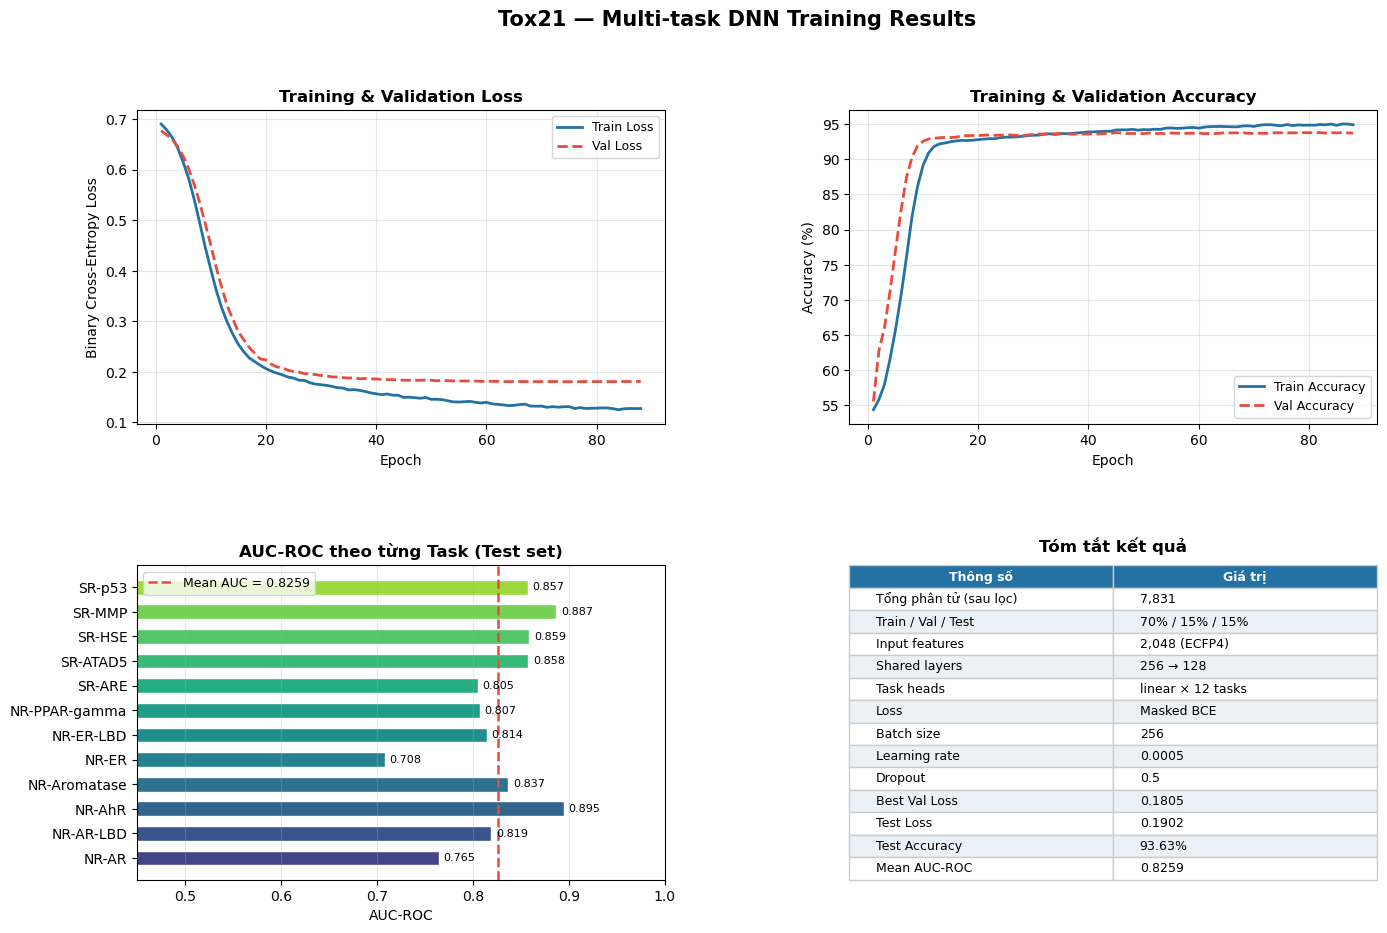

✓ Đã lưu biểu đồ: tox21_results.png


In [89]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Tox21 — Multi-task DNN Training Results",
             fontsize=15, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

COLOR_TRAIN = "#2471A3"
COLOR_VAL   = "#E74C3C"

# ── 1: Loss ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, history["train_loss"], color=COLOR_TRAIN, lw=2, label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   color=COLOR_VAL,   lw=2, ls="--", label="Val Loss")
ax1.set_title("Training & Validation Loss", fontsize=12, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Binary Cross-Entropy Loss")
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

# ── 2: Accuracy ────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, history["train_acc"], color=COLOR_TRAIN, lw=2, label="Train Accuracy")
ax2.plot(epochs_range, history["val_acc"],   color=COLOR_VAL,   lw=2, ls="--", label="Val Accuracy")
ax2.set_title("Training & Validation Accuracy", fontsize=12, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

# ── 3: AUC per task ────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
colors_bar = plt.cm.viridis(np.linspace(0.2, 0.85, len(task_aucs)))
bars = ax3.barh(TASKS[:len(task_aucs)], task_aucs, color=colors_bar, edgecolor="white", height=0.6)
ax3.axvline(mean_auc, color=COLOR_VAL, ls="--", lw=1.8, label=f"Mean AUC = {mean_auc:.4f}")
ax3.set_xlim(0.45, 1.0)
ax3.set_title("AUC-ROC theo từng Task (Test set)", fontsize=12, fontweight="bold")
ax3.set_xlabel("AUC-ROC"); ax3.legend(fontsize=9); ax3.grid(True, axis="x", alpha=0.3)
for bar, auc in zip(bars, task_aucs):
    ax3.text(auc + 0.005, bar.get_y() + bar.get_height() / 2,
             f"{auc:.3f}", va="center", fontsize=8)

# ── 4: Summary table ───────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis("off")
summary_data = [
    ["Tổng phân tử (sau lọc)",  f"{len(X_all):,}"],
    ["Train / Val / Test",      "70% / 15% / 15%"],
    ["Input features",          f"{X_all.shape[1]:,} (ECFP4)"],
    ["Shared layers",           "256 → 128"],
    ["Task heads",              f"linear × {len(TASKS)} tasks"],
    ["Loss",                    "Masked BCE"],
    ["Batch size",              str(BATCH_SIZE)],
    ["Learning rate",           str(LR)],
    ["Dropout",                 str(DROPOUT)],
    ["Best Val Loss",           f"{best_val_loss:.4f}"],
    ["Test Loss",               f"{test_loss:.4f}"],
    ["Test Accuracy",           f"{test_acc:.2f}%"],
    ["Mean AUC-ROC",            f"{mean_auc:.4f}"],
]
tbl = ax4.table(cellText=summary_data, colLabels=["Thông số", "Giá trị"],
                cellLoc="left", loc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor("#CCCCCC")
    if row == 0:
        cell.set_facecolor("#2471A3"); cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EAF2F8")
ax4.set_title("Tóm tắt kết quả", fontsize=12, fontweight="bold", pad=10)

plt.savefig("tox21_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Đã lưu biểu đồ: tox21_results.png")


## 13. Lưu mô hình

In [90]:
torch.save({
    "model_state_dict"    : model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_epoch"          : best_epoch,
    "mean_auc"            : mean_auc,
    "history"             : history,
    "tasks"               : TASKS,
    "input_dim"           : X_all.shape[1],
}, "tox21_multitask_dnn.pth")
print("✓ Đã lưu mô hình: tox21_multitask_dnn.pth")

# Xuất kết quả theo task ra CSV
results_df.to_csv("tox21_task_results.csv", index=False)
print("✓ Đã lưu kết quả: tox21_task_results.csv")
print("\n--- Kết quả cuối cùng ---")
print(results_df.to_string(index=False))


✓ Đã lưu mô hình: tox21_multitask_dnn.pth
✓ Đã lưu kết quả: tox21_task_results.csv

--- Kết quả cuối cùng ---
         Task  AUC-ROC  Accuracy (%)  #Samples
        NR-AR 0.764553     96.837209      1075
    NR-AR-LBD 0.819177     97.397397       999
       NR-AhR 0.894537     91.124871       969
 NR-Aromatase 0.836832     96.856810       859
        NR-ER 0.708287     88.755459       916
    NR-ER-LBD 0.814446     96.518375      1034
NR-PPAR-gamma 0.807155     97.280335       956
       SR-ARE 0.804954     85.294118       884
     SR-ATAD5 0.857848     95.852969      1061
       SR-HSE 0.858911     94.588970       961
       SR-MMP 0.886665     88.952819       869
       SR-p53 0.857346     94.088670      1015
